In [2]:
import pandas as pd

In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import numpy as np

In [3]:
f=pd.read_csv("Fish.csv")
df=pd.DataFrame(f)

In [4]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [19]:
x=df[["Length1","Length2","Length3","Height","Width"]]
y=df["Weight"]

In [20]:
Xtrain, Xtest, ytrain, ytest = train_test_split(x,y,test_size = 0.2, random_state=42)

In [ ]:
poly=PolynomialFeatures(degree=3)
x_poly_train=poly.fit_transform(Xtrain)
x_poly_text=poly.transform(Xtest)

model = LinearRegression()
model.fit(x_poly_train, ytrain)

predictions = model.predict(x_poly_text)

acc = r2_score(predictions, ytest)
mse = mean_squared_error(ytest, predictions)
print(acc, mse)

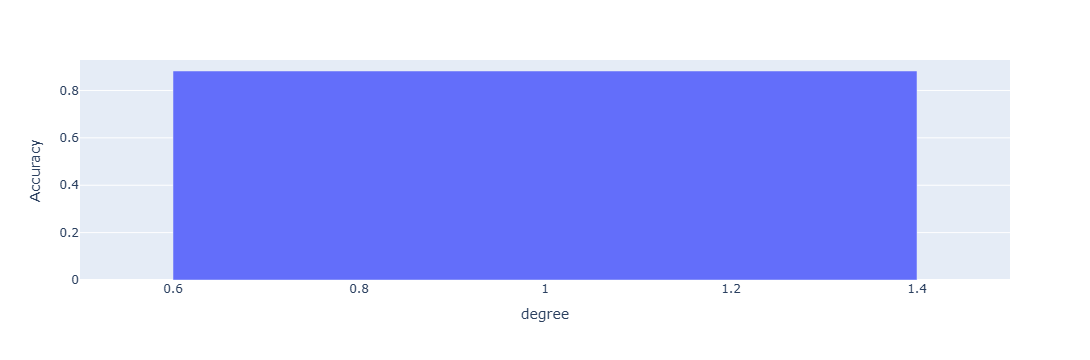

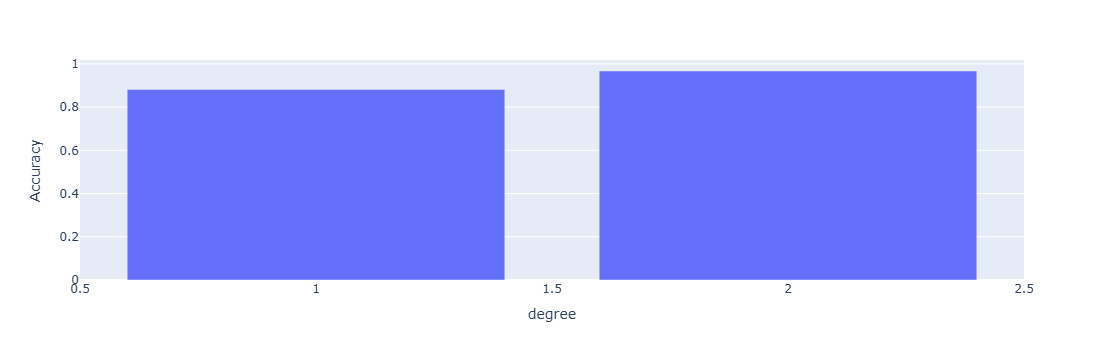

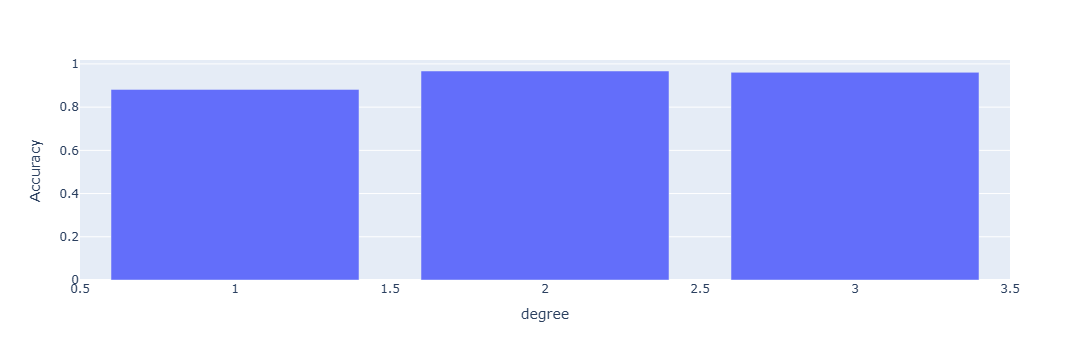

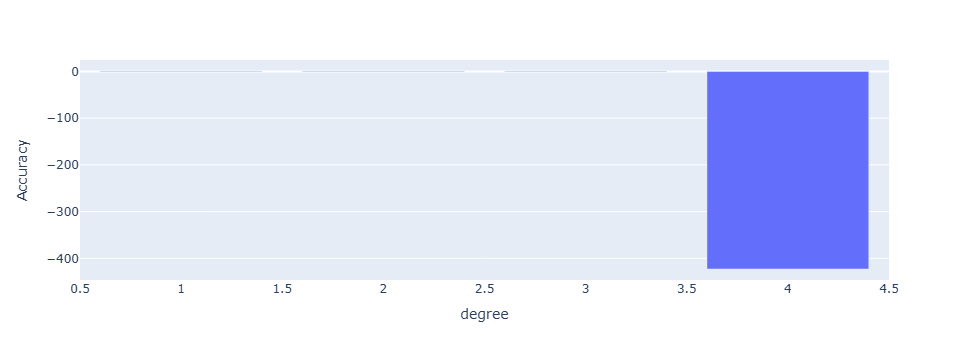

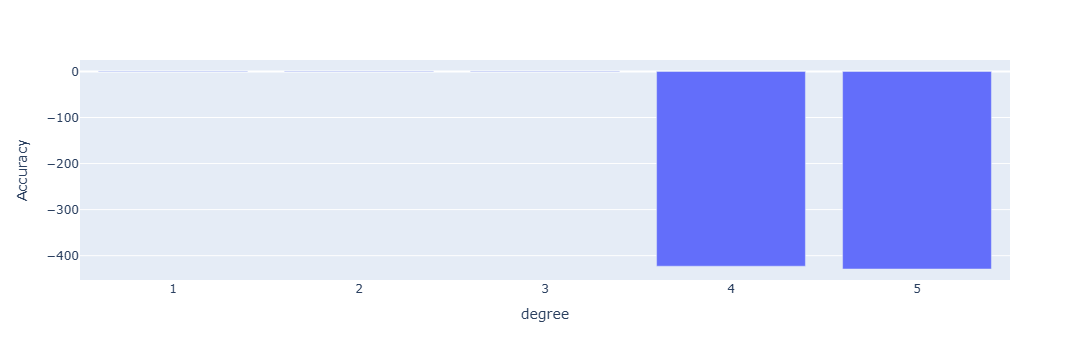

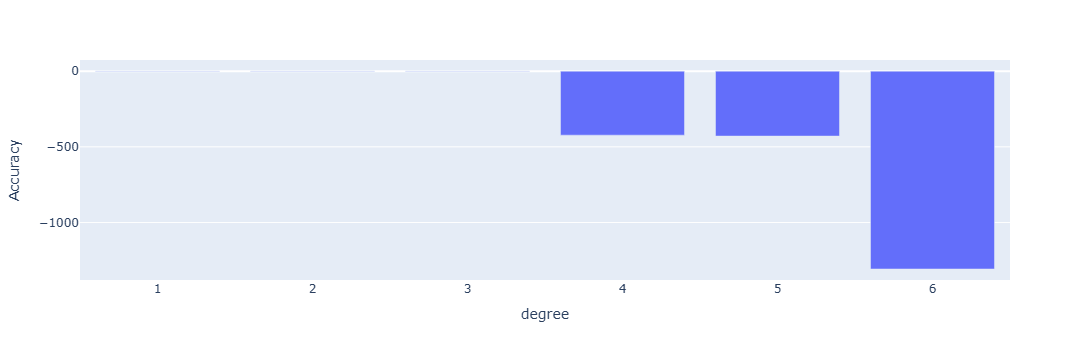

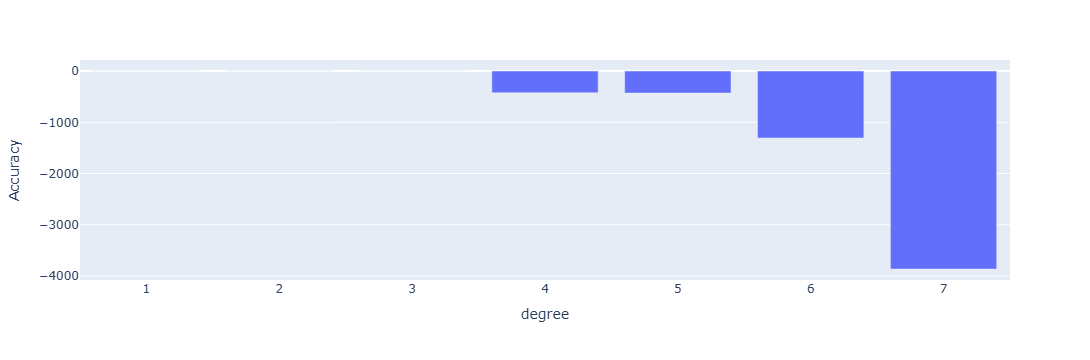

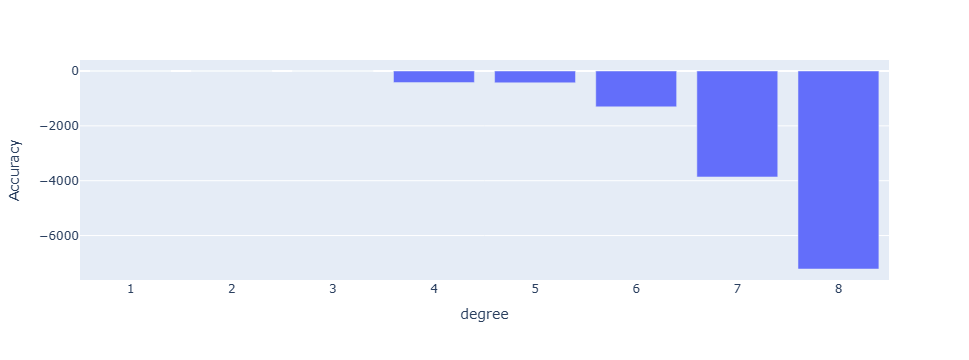

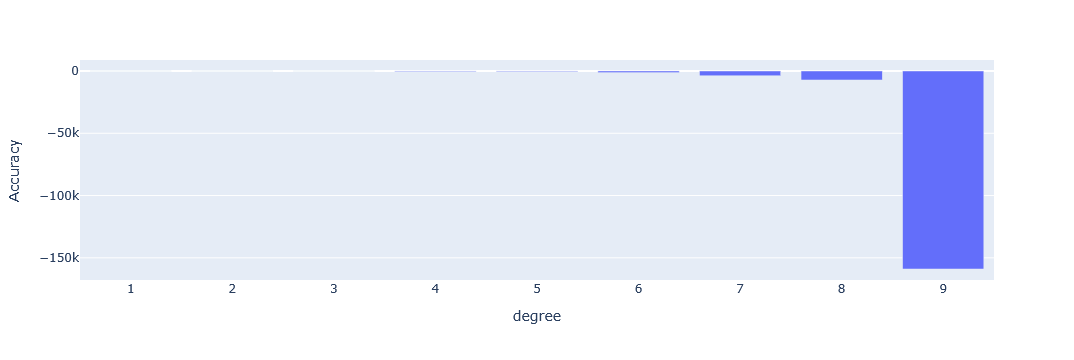

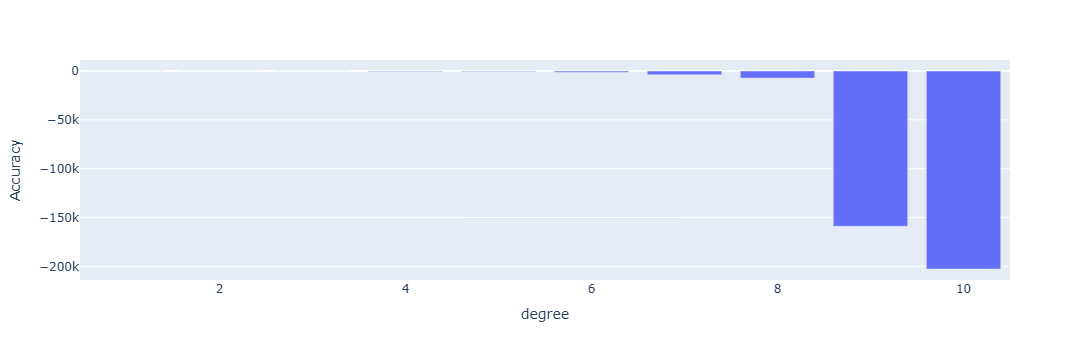

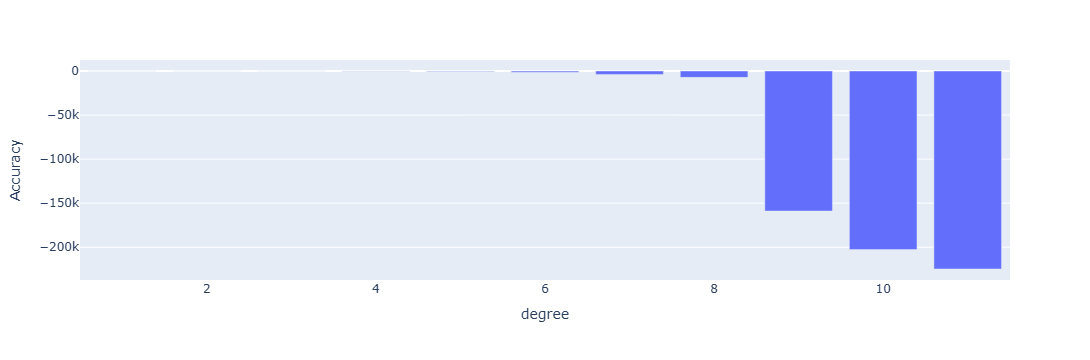

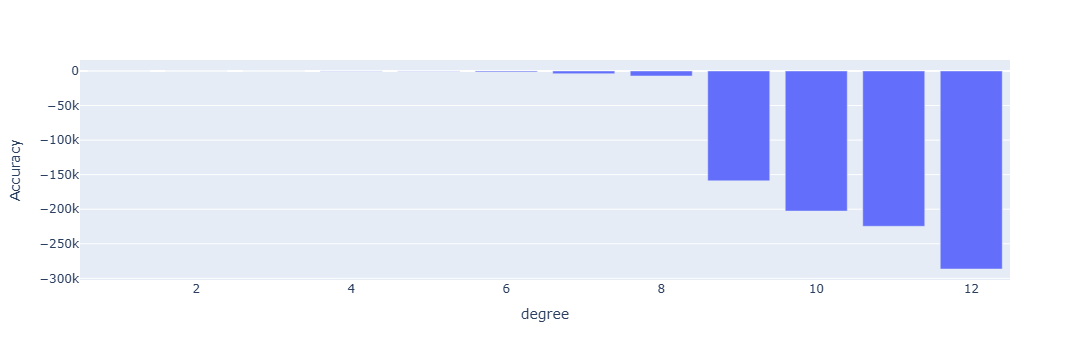

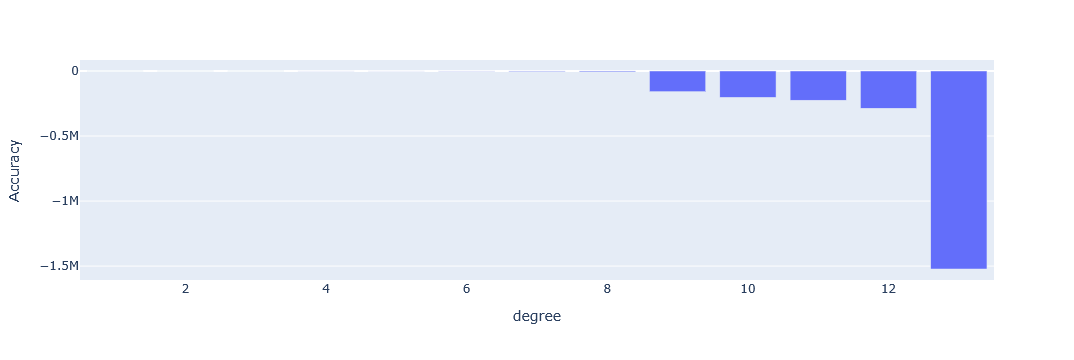

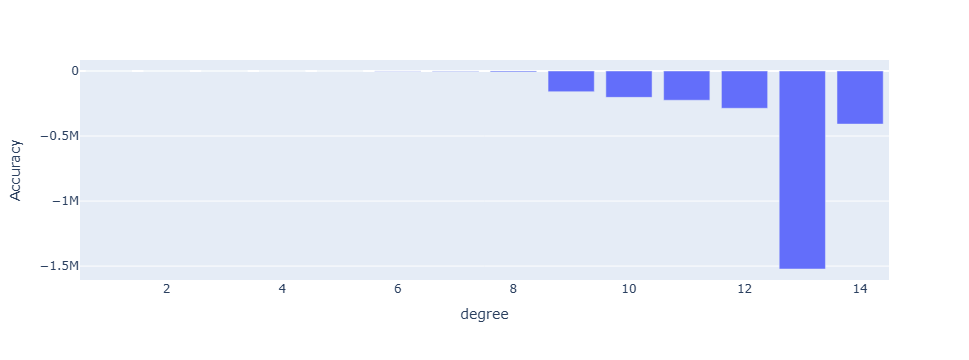

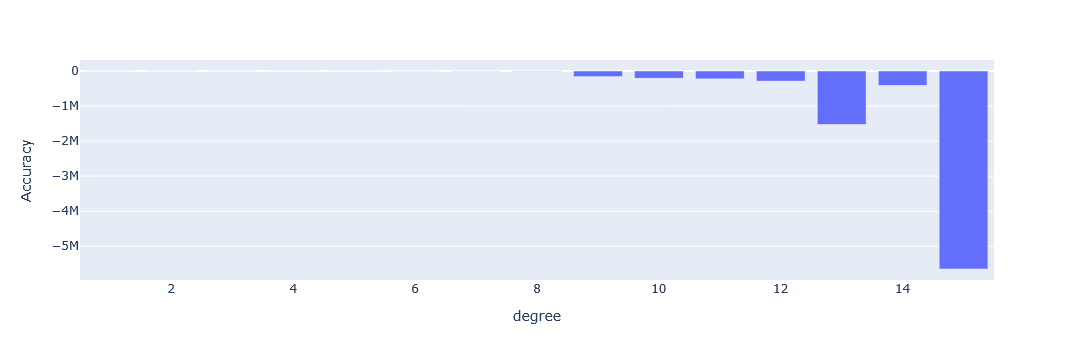

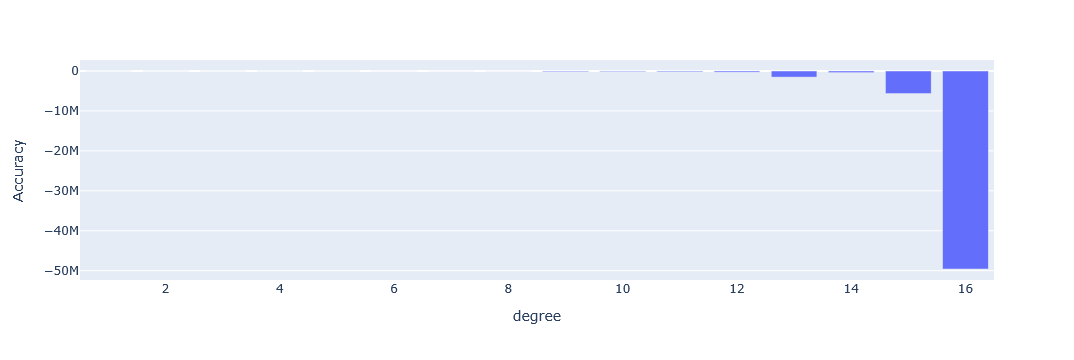

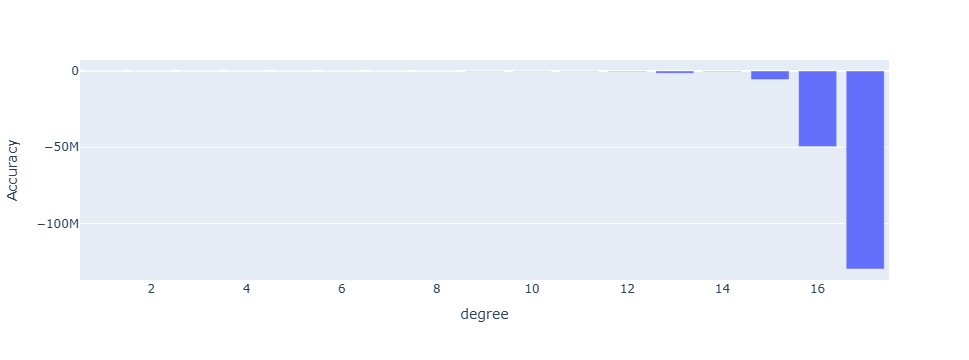

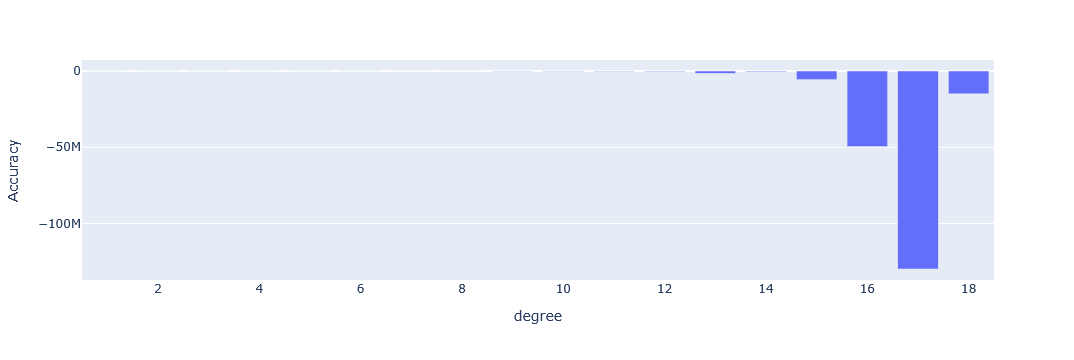

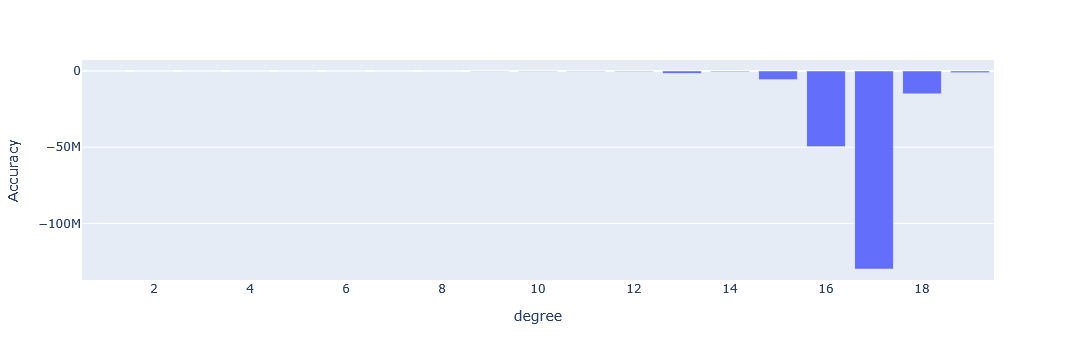

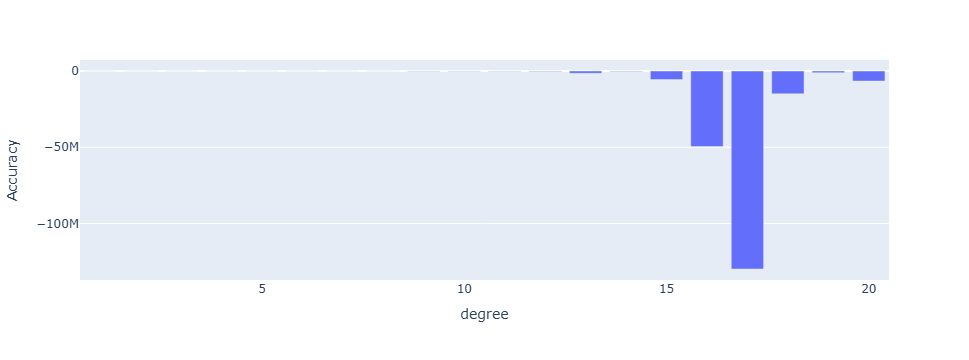

In [29]:
data={}
result=[]
for i in range(1,21):
    poly=PolynomialFeatures(degree=i)
    x_poly_train=poly.fit_transform(Xtrain)
    x_poly_text=poly.transform(Xtest)
    model = LinearRegression()
    model.fit(x_poly_train, ytrain)
    predictions = model.predict(x_poly_text)
    acc = r2_score(ytest,predictions)
    data[i]=acc
    result.append({"degree":i,"Accuracy":acc})
    fig=px.bar(result,x="degree",y="Accuracy")
    fig.show()

## Question1
```
For x = np.array([5, 15, 25, 35, 45, 55]) and y = np.array([5, 20, 14, 32, 22, 38]), apply simple linear regression using scikit learn library and calculate calculate R squared, coeficient and intercept. Predict the y values for x = np.arange(5). (Don't split data for training/testing)
```

In [40]:
x=np.array([5,15,25,35,45,55]).reshape(-1,1)
y=np.array([5,20,14,32,22,38])
model=LinearRegression()
model.fit(x,y)
score=model.score(x,y)
score
intercept=model.intercept_
ceofi=model.coef_
print(score)
print(intercept)
print(ceofi)
pre=model.predict(np.arange(5).reshape(-1,1))
print(pre)

0.715875613747954
5.633333333333329
[0.54]
[5.63333333 6.17333333 6.71333333 7.25333333 7.79333333]


In [39]:
pre=model.predict(x)
r2_score(y,pre)

0.715875613747954

## Question2
```
Given a dataset with 'SAT' scores as independent variables and 'GPA' as the dependent variable,  calculate R squared, coeficient and intercept using linear regression and scikitlearn library. (Don't split data for training/testing)
```

In [41]:
f=pd.read_csv("SATGPA.csv")
df=pd.DataFrame(f)

In [42]:
df

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76


In [43]:
x=df[["SAT"]]
y=df["GPA"]
model=LinearRegression()
model.fit(x,y)
score=model.score(x,y)
intercept=model.intercept_
c=model.coef_
print(score)
print(intercept)
print(c)

0.40600391479679765
0.2750402996602803
[0.00165569]


## Question3
```
Given a real estate price size year dataset, implement multiple linear regression using scikitlearn library. Using the model, make a prediction about an apartment price with size 750 sq.ft. for 2009.Also Calculate R squared, coeficient and intercept. (Don't split data for training/testing)
```

In [45]:
f=pd.read_csv("real_estate.csv")
df=pd.DataFrame(f)
df

,price,size,year
0,234314.144,643.09,2015
1,228581.528,656.22,2009
2,281626.336,487.29,2018
3,401255.608,1504.75,2015
4,458674.256,1275.46,2009
...,...,...,...
95,252460.400,549.80,2009
96,310522.592,1037.44,2009
97,383635.568,1504.75,2006
98,225145.248,648.29,2015


In [46]:
x=df[["size","year"]]
y=df["price"]
model=LinearRegression()
model.fit(x,y)
score=model.score(x,y)
intercept=model.intercept_
c=model.coef_
print(score)
print(intercept)
print(c)
pre=model.predict([[750,2009]])
print(pre)

0.7764803683276791
-5772267.017463281
[ 227.70085401 2916.78532684]
[258330.34465995]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



## Question4

## Question5
```
For x = np.arange(0, 30) and y = np.array([3, 4, 5, 7, 10, 8, 9, 10, 10, 23, 27, 44, 50, 63, 67, 60, 62, 70, 75, 88, 81, 87, 95, 100, 108, 135, 151, 160, 169, 179]), apply polynomial regression using scikit learn library and calculate  R squared, coeficient and intercept. Predict the y values for x = np.arange(5). (Don't split data for training/testing)
```

In [5]:
x = np.arange(0, 30).reshape(-1,1)
y = np.array([3, 4, 5, 7, 10, 8, 9, 10, 10, 23, 27, 44, 50, 63, 67, 60, 62, 70, 75, 88, 81, 87, 95, 100, 108, 135, 151, 160, 169, 179])

In [8]:
poly=PolynomialFeatures()
x_poly=poly.fit_transform(x)

model=LinearRegression()
model.fit(x_poly,y)

r2 = model.score(x_poly, y)
coefficients = model.coef_
intercept = model.intercept_

x_new = np.arange(5).reshape(-1, 1)
x_new_poly = poly.transform(x_new)
y_pred = model.predict(x_new_poly)

print("R²:", r2)
print("Coefficients:", coefficients)
print("Intercept:", intercept)
print("Predicted y:", y_pred)

R²: 0.9742355121173141
Coefficients: [0.         1.17020102 0.16361433]
Intercept: 1.7080645161290278
Predicted y: [1.70806452 3.04187987 4.70292388 6.69119657 9.00669792]


## PB229
```
Consider variables x and y created from a pandas dataframe  “car.csv” .
Create new column named “Age_car” (Age_car=2023-year)
For multiple linear regression problem, x contains the independent variables ( Age_car , Driven_kms , Fuel_Type , Selling_type , 
Transmission )  and y contains the dependent (Selling_Price) variable which is to be predicted.
Write a Python program to spilt x and y into training and testing datasets with a 20% split. Then create a multiple linear 
regression model using the training data and print its coefficients ,intercept and mean squared e
```rror.

In [73]:
import pandas as pd

f=pd.read_csv("car data1.csv")
df=pd.DataFrame(f)
df

df["Age_car"]=2023-df["Year"]

df

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

x=df[["Age_car","Kms_Driven","Fuel_Type","Seller_Type","Transmission"]]
y=df["Selling_Price"]

x=pd.get_dummies(x)

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

model=LinearRegression()
model.fit(x_train,y_train)
pre=model.predict(x_test)
pre

print(r2_score(y_test,pre))
print(mean_squared_error(y_test,pre))
print(model.intercept_)
print(model.coef_)

pre1=model.predict([[18,55000,0,0,1,0,1,0,1]])

pre1

x_train

df.iloc[4]

pre2=model.predict([[9,42450,0,1,0,1,0,0,1]])

pre2

0.5911495663366259
9.418108720809975
8.983338776811964
[-2.79387747e-01 -4.48042783e-06 -2.55192308e+00  3.85735270e+00
 -1.30542962e+00  2.05551251e+00 -2.05551251e+00  2.40151693e+00
 -2.40151693e+00]


C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9.79000318])

## PB228
```
Write a program to create a Model using linear regression to predict the wine quality using the csv file provided named 
“winequality.csv”. Do the required process in the data before making a model. 
If you find any null value in “winequality.csv” then replace null value with mean value of respected columns.
Find co-efficient, intercept and mean squared error.
also Predict the quality of red wine for the following data:                       
fixed acidity: 8            
vola le acidity: 0.4       
citric acid: 0.40                
residual sugar: 15          
chlorides: 0.048                  
free sulfur dioxide: 40      
total sulfur dioxide: 150     
density: 0.99                  
pH: 3                      
sulphates: 0.45                
alcohol: 10.5
```

In [76]:
f=pd.read_csv("winequalityN.csv")

In [77]:
df=pd.DataFrame(f)
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [78]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [79]:
df["volatile acidity"].fillna(df["volatile acidity"].mean(),inplace=True)
df["fixed acidity"].fillna(df["fixed acidity"].mean(),inplace=True)
df["citric acid"].fillna(df["citric acid"].mean(),inplace=True)
df["residual sugar"].fillna(df["residual sugar"].mean(),inplace=True)
df["chlorides"].fillna(df["chlorides"].mean(),inplace=True)
df["sulphates"].fillna(df["sulphates"].mean(),inplace=True)
df["pH"].fillna(df["pH"].mean(),inplace=True)

C:\Users\yasha\AppData\Local\Temp\ipykernel_12480\1305508892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["volatile acidity"].fillna(df["volatile acidity"].mean(),inplace=True)
C:\Users\yasha\AppData\Local\Temp\ipykernel_12480\1305508892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [80]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.450000,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.490000,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.440000,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.580000,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.531215,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.750000,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.710000,10.2,5


In [81]:
df.isnull().sum()


type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [90]:
x=df[["type","fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide",
     "density","pH","sulphates","alcohol"]]
y=df["quality"]
x=pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

model=LinearRegression()
model.fit(x_train,y_train)
pre=model.predict(x_test)
print(pre)
print(r2_score(y_test,pre))
print(mean_squared_error(y_test,pre))
print(model.intercept_)
print(model.coef_)

[6.34992927 6.02349546 5.76827822 ... 5.58298533 5.68576899 5.43735072]
0.34048454089868496
0.47142125991978623
96.51870294510934
[ 7.87101728e-02 -1.47184596e+00 -4.10628390e-02  6.07094439e-02
 -6.70234962e-01  5.27960941e-03 -1.64982333e-03 -9.56364968e+01
  4.40108968e-01  7.34056038e-01  2.27705826e-01  1.70732896e-01
 -1.70732896e-01]


In [86]:
x_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_red,type_white
1916,6.6,0.25,0.36,8.1,0.045,54.0,180.0,0.99580,3.08,0.42,9.2,False,True
947,8.5,0.16,0.35,1.6,0.039,24.0,147.0,0.99350,2.96,0.36,10.0,False,True
877,6.0,0.28,0.34,1.6,0.119,33.0,104.0,0.99210,3.19,0.38,10.2,False,True
2927,7.0,0.31,0.31,9.1,0.036,45.0,140.0,0.99216,2.98,0.31,12.0,False,True
6063,8.5,0.44,0.50,1.9,0.369,15.0,38.0,0.99634,3.01,1.10,9.4,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,6.3,0.24,0.29,13.7,0.035,53.0,134.0,0.99567,3.17,0.38,10.6,False,True
5191,6.9,0.36,0.25,2.4,0.098,5.0,16.0,0.99640,3.41,0.60,10.1,True,False
5226,13.4,0.27,0.62,2.6,0.082,6.0,21.0,1.00020,3.16,0.67,9.7,True,False
5390,8.9,0.40,0.51,2.6,0.052,13.0,27.0,0.99500,3.32,0.90,13.4,True,False


In [88]:
pre1=model.predict([[8,0.4,0.40,15,0.048,40,150,0.99,3,0.45,10.5,1,0]])

C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [89]:
pre1

array([6.91756645])

## PB230
```
Write a python program for following tasks - 
Make sure all the required libraries are imported at the beginning of the Jupyter Notebook.
 a)Load the windpower dataset into the notebook.
 b)Check records for any missing values and remove them permanently using appropriate method.
 c)Treat windspeed as the independent variable and power as the dependent variable. Split the dataset into training (75%) and 
testing (25%) sets using random state of 42.
 d)Use scikit-learn to train polynomial regression models of degrees 3, 4, 5, and 6.
 e)Predict power values on the test set and print the Mean Squared Error (MSE) and R² score (coefficient of determinaon) for 
each polynomial degree.
 f)Plot actual vs. predicted power values for all polynomial degrees on the same graph for comparison and label the plot 
accordingly.
 g)Create a plot showing MSE vs. polynomial degree. Which degree has the lowest MSE? Write in the comment.
 h)Print the coefficients and intercept for each trained polynomial regression model.
```

# KNN

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [65]:
f=pd.read_csv("Fish.csv")
df=pd.DataFrame(f)
x=df.drop(["Species"],axis=1)
y=df["Species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc)

0.4791666666666667


In [66]:
df["Species"].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [67]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [68]:
x_train

,Weight,Length1,Length2,Length3,Height,Width
85,130.0,19.3,21.3,22.8,6.3840,3.5340
81,85.0,18.2,20.0,21.0,5.0820,2.7720
112,685.0,34.0,36.5,39.0,10.8810,6.8640
11,500.0,28.7,31.0,36.2,14.3714,4.8146
109,514.0,30.5,32.8,34.0,10.0300,6.0180
...,...,...,...,...,...,...
71,300.0,24.0,26.0,29.0,11.3680,4.2340
106,250.0,25.9,28.0,29.4,7.8204,4.2042
14,600.0,29.4,32.0,37.2,14.9544,5.1708
92,150.0,20.5,22.5,24.0,6.7920,3.6240


In [69]:
pre1=model.predict([[242.0,23.2,25.4,30.0,11.5200,4.0200]])
pre1

C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Perch'], dtype=object)

In [70]:
result=[]
data={}
for i in range(1,21):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    predictions = model.predict(x_test)
    acc = r2_score(y_test,predictions)
    data[i]=acc
    # result.append({"degree":i,"Accuracy":acc})

print(result)
print("--------")
print(max(data,key=data.get))
print(max(data.values()))

ValueError: could not convert string to float: 'Perch'

In [122]:
data={
    "Movie":["M1","M2","M3","M4","M5","M6"],
    "duration":[150,120,90,100,140,95],
    "ActionLevel":[9,8,2,3,7,4],
    "Genre":["A","A","C","C","A","C"]
}
df=pd.DataFrame(data)
df

,Movie,duration,ActionLevel,Genre
0,M1,150,9,A
1,M2,120,8,A
2,M3,90,2,C
3,M4,100,3,C
4,M5,140,7,A
5,M6,95,4,C


In [123]:
x=df[["duration","ActionLevel"]]
y=df["Genre"]

In [126]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [127]:
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc)

0.0


In [128]:
pre1=model.predict([[110,6]])

C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [129]:
pre1

array(['C'], dtype=object)

# CONFUSION MATRIX

In [116]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pandas as pd
from sklearn.model_selection import train_test_split

In [117]:
f=pd.read_csv("diabetes.csv")
df=pd.DataFrame(f)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [118]:
x=df.drop(["Outcome"],axis=1)
y=df["Outcome"]

In [119]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [120]:
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc)

0.6753246753246753


In [81]:
data={}
for i in range(1,11):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    acc=accuracy_score(y_test,pre)
    data[i]=acc
print(max(data,key=data.get))
print(max(data.values()))

10
0.7662337662337663


In [121]:
arr=confusion_matrix(y_test,pre)

In [122]:
arr

array([[108,  43],
       [ 32,  48]], dtype=int64)

In [123]:
total=arr[0][0]+arr[0][1]+arr[1][0]+arr[1][1]

In [124]:
accuracy=(arr[0][0]+arr[1][1])/total

In [125]:
accuracy

0.6753246753246753

In [126]:
err=1-accuracy
err

0.3246753246753247

In [127]:
precision=arr[0][0]/(arr[0][0]+arr[1][0])
precision

0.7714285714285715

In [128]:
recall=arr[0][0]/(arr[0][0]+arr[0][1])
recall

0.7152317880794702

In [129]:
speci=arr[1][1]/(arr[1][0]+arr[1][1])
speci

0.6

In [130]:
print(classification_report(y_test,pre))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74       151
           1       0.53      0.60      0.56        80

    accuracy                           0.68       231
   macro avg       0.65      0.66      0.65       231
weighted avg       0.69      0.68      0.68       231



<Axes: >

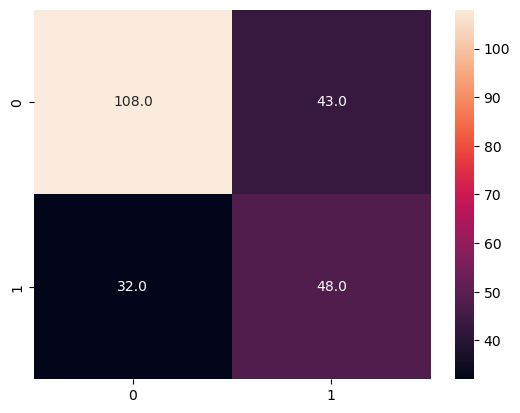

In [131]:
sns.heatmap(arr,annot=True,fmt="0.1f")

In [107]:
sns.heatmap??

Signature:
sns.heatmap(
    data,
    *,
    vmin=None,
    vmax=None,
    cmap=None,
    center=None,
    robust=False,
    annot=None,
    fmt='.2g',
    annot_kws=None,
    linewidths=0,
    linecolor='white',
    cbar=True,
    cbar_kws=None,
    cbar_ax=None,
    square=False,
    xticklabels='auto',
    yticklabels='auto',
    mask=None,
    ax=None,
    **kwargs,
)
Source:   
def heatmap(
    data, *,
    vmin=None, vmax=None, cmap=None, center=None, robust=False,
    annot=None, fmt=".2g", annot_kws=None,
    linewidths=0, linecolor="white",
    cbar=True, cbar_kws=None, cbar_ax=None,
    square=False, xticklabels="auto", yticklabels="auto",
    mask=None, ax=None,
    **kwargs
):
    """Plot rectangular data as a color-encoded matrix.

    This is an Axes-level function and will draw the heatmap into the
    currently-active Axes if none is provided to the ``ax`` argument.  Part of
    this Axes space will be taken and used to plot a colormap, unless ``cbar``
    is False or a

In [132]:
actual=[0,1,0,0,0,1,0,1,0,1]
predict=[1,1,0,0,1,1,0,1,1,0]
CN=confusion_matrix(actual,predict)
CN

array([[3, 3],
       [1, 3]], dtype=int64)

In [133]:
import seaborn as sns

<Axes: >

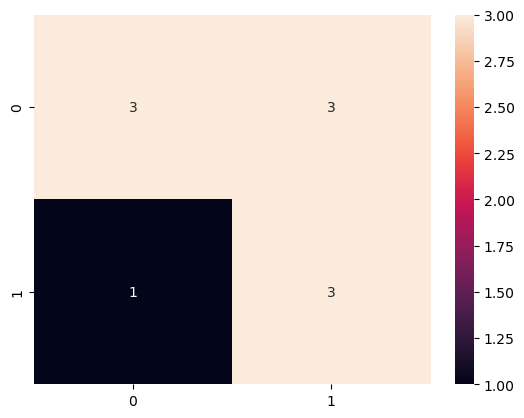

In [134]:
sns.heatmap(CN,annot=True)

In [135]:
model.classes_

array([0, 1], dtype=int64)

### PB266
```
Using the Iris dataset 
(https://raw.githubusercontent.com/pdsinroza/python2/main/Iris.csv?token=GHSAT0AAAAAACQ7ZNWMQ3U6FOFL37O2JIPAZ
Q5CWZA), write Python code to perform the following tasks:
Split the dataset into features (X) and labels (y).
Split the features and labels into training and testing sets with a test size of 0.2 and a random state of 42.
Initialize a kNN classifier with 3 neighbors.
Train the classifier on the training set.
Make predictions on the test set.
Calculate and print the accuracy score of the cla
```ssifier.

In [136]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [137]:
f=pd.read_csv("iris.csv")
df=pd.DataFrame(f)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor


In [138]:
df=df.drop(["Id"],axis=1)

In [139]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
97,6.2,2.9,4.3,1.3,Iris-versicolor
98,5.1,2.5,3.0,1.1,Iris-versicolor


In [140]:
x=df.drop(["Species"],axis=1)
y=df["Species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [141]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)

In [142]:
print(acc)

1.0


## Decision Tree

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
f=pd.read_csv("drug200.csv")
df=pd.DataFrame(f)
x=df.drop("Drug",axis=1)
y=df["Drug"]
x=pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=DecisionTreeClassifier(criterion="entropy")
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
acc

1.0

In [4]:
x_train

,Age,Na_to_K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
169,20,11.262,True,False,True,False,False,True,False
97,56,25.395,True,False,True,False,False,True,False
31,74,9.567,False,True,True,False,False,True,False
12,43,15.376,False,True,False,True,False,True,False
35,46,7.285,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...
106,22,11.953,False,True,False,False,True,True,False
14,50,12.703,True,False,False,False,True,True,False
92,29,29.450,True,False,True,False,False,True,False
179,67,15.891,True,False,False,False,True,True,False


In [7]:
pre1=model.predict([[20,11.262,1,0,1,0,0,1,0]])
pre1

C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['drugA'], dtype=object)